# Main Bearing OpEx Sensitivity Analysis Study
National Renewable Energy Laboratory\
Daniel Mulas Hernando\
28 November 2025

This notebook allows you to specify the random seeds—and thus control the number of simulations—to run for this particular case. For each simulation, it calculates and saves the availability, OpEx, and vessel cost breakdowns. All results are stored in the `library/base_2024/results` folder for easy access and analysis.

In [1]:
import pandas as pd
from pathlib import Path
from wombat.core import Simulation, Metrics

In [2]:
from pathlib import Path
import pandas as pd
from wombat import Simulation, Metrics  # adjust import if needed
from wombat.utilities import plot


def run_windfarm_simulations(technology: str, random_seeds: list, library_path : str, port_name="base_port_139km"):
    """
    Run simulations for a specified wind farm technology and save
    availability, OpEx, vessel costs, and repair time at port.

    Supported technologies:
      - 'fixed_bottom'
      - 'floating'
    
    Parameters:
    - technology: str, one of the supported technology names
    - random_seeds: list of ints, random seeds for reproducibility
    - port_name: str, name of the port to track repair time

    Saves CSV files in library/exxon/results with appropriate naming.
    """

    # === CONFIGURATION ===
    library_path = Path(library_path).resolve()
    results_dir = library_path / "results"
    results_dir.mkdir(parents=True, exist_ok=True)

    # === CONFIG SELECTION ===
    config_map = {
        "ATB3_3_baseline_ATB": "ATB3_3_baseline_ATB.yaml",
        "ATB3_3_design_ATB": "ATB3_3_design_ATB.yaml",
        "ATB3_3_miba-case-0": "ATB3_3_miba-case-0.yaml",
        "ATB3_3_miba-case-1": "ATB3_3_miba-case-1.yaml",
        "ATB3_3_miba-case-2": "ATB3_3_miba-case-2.yaml", # 5% in plant lifetime, beta = 1 for major repair
        "ATB3_3_miba-case-2b": "ATB3_3_miba-case-2b.yaml", # 5% in plant lifetime, beta = 1 for major repair
        "ATB3_3_miba-case-3": "ATB3_3_miba-case-3.yaml",
        "ATB3_3_miba-case-4-5yrs": "ATB3_3_miba-case-4-5yrs.yaml",
        "ATB3_3_miba-case-4-25yrs": "ATB3_3_miba-case-4-25yrs.yaml",
        "ATB3_3_miba-case-4b-5yrs": "ATB3_3_miba-case-4b-5yrs.yaml",
    }

    # Validate input
    tech_key = technology
    if tech_key not in config_map:
        raise ValueError(
            f"Invalid technology '{technology}'. Must be one of: "
            f"{', '.join(config_map.keys())}"
        )

    config_name = config_map[tech_key]

    # === STORAGE INITIALIZATION ===
    availability_records = []
    opex_records = []
    vessel_records = []
    repair_time_records = []
    requests_dfs = []
    cost_by_component_dfs = []

    # === RUN SIMULATIONS SEQUENTIALLY ===
    for i, seed in enumerate(random_seeds, start=1):
        print(f"\r🚀 Running simulation {i}/{len(random_seeds)} with seed {seed}...", end="", flush=True)

        # Run simulation
        sim = Simulation(
            library_path=library_path,
            config=config_name,
            random_seed=seed
        )
        sim.run(create_metrics=True, save_metrics_inputs=True)

        # Load metrics
        fpath = sim.env.metrics_input_fname.parent
        fname = sim.env.metrics_input_fname.name
        metrics = Metrics.from_simulation_outputs(fpath, fname)

        # === 1. Availability Results ===
        time_avail = metrics.time_based_availability(frequency="project", by="windfarm")
        prod_avail = metrics.production_based_availability(frequency="project", by="windfarm")
        availability_records.append({
            "run": i,
            "random_seed": seed,
            "time_based_availability": time_avail.iloc[0, 0],
            "production_based_availability": prod_avail.iloc[0, 0],
        })

        # === 2. OpEx Results ===
        opex_df = metrics.opex(frequency="annual", by_category=True).reset_index()
        opex_df.insert(0, "random_seed", seed)
        opex_df.insert(0, "run", i)
        opex_records.append(opex_df)

        #check plot
        #plot.plot_farm_availability(sim=sim, which="time", farm_95_CI=False)

        # === 3. Vessel Costs ===
        vessel_df = metrics.equipment_costs(frequency="annual", by_equipment=True).reset_index()
        vessel_df.insert(0, "random_seed", seed)
        vessel_df.insert(0, "run", i)
        vessel_records.append(vessel_df)

        # === 4. Repair Time at Port ===
        events_df = sim.env.load_events_log_dataframe()
        events_df['duration'] = pd.to_numeric(events_df['duration'], errors='coerce')
        df_port = events_df[events_df['agent'] == port_name]
        total_hours = df_port['duration'].sum()
        simulation_years = sim.env.end_year - sim.env.start_year + 1
        avg_hours_per_year = total_hours / simulation_years
        avg_days_per_year = avg_hours_per_year / 24
        avg_months_per_year = avg_hours_per_year / (24 * 30.4375)

        repair_time_records.append({
            "run": i,
            "random_seed": seed,
            "avg_repair_time_months": avg_months_per_year,
            "avg_repair_time_days": avg_days_per_year
        })

        # === 4. Requests Summary ===
        requests = metrics.request_summary()
        requests.insert(0, "random_seed", seed)
        requests.insert(0, "run", i)
        requests_dfs.append(requests)

        # === 5. Cost By Component ===
        cost_by_component = metrics.component_costs(frequency="project", by_category=True, by_action=True)
        cost_by_component.insert(0, "random_seed", seed)
        cost_by_component.insert(0, "run", i)
        cost_by_component_dfs.append(cost_by_component)

        
        # Cleanup logs
        sim.env.cleanup_log_files()

    # === COMBINE AND SAVE RESULTS ===
    df_availability = pd.DataFrame(availability_records)
    df_opex = pd.concat(opex_records, ignore_index=True)
    df_vessels = pd.concat(vessel_records, ignore_index=True)
    df_repair_time = pd.DataFrame(repair_time_records)
    df_requests = pd.concat(requests_dfs)
    df_cost_by_component = pd.concat(cost_by_component_dfs)

    df_availability.to_csv(results_dir / f"COWER-2025-{technology}_all_availability_results.csv", index=False)
    df_opex.to_csv(results_dir / f"COWER-2025-{technology}_all_opex_results.csv", index=False)
    df_vessels.to_csv(results_dir / f"COWER-2025-{technology}_all_vessel_results.csv", index=False)
    df_repair_time.to_csv(results_dir / f"COWER-2025-{technology}_repair_time_at_port_results.csv", index=False)
    df_requests.to_csv(results_dir / f"COWER-2025-{technology}_requests_results.csv")
    df_cost_by_component.to_csv(results_dir / f"COWER-2025-{technology}_cost_by_component_results.csv")
    
    print(f"\r✅ All {technology} simulations complete. Results saved to {results_dir}        ")

    return events_df


In [3]:
NUM_RUNS = 25

# Run base ATB case
#sim_ATB3_3_baseline_ATB = run_windfarm_simulations("ATB3_3_baseline_ATB", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run design ATB case
#sim_ATB3_3_design_ATB = run_windfarm_simulations("ATB3_3_design_ATB", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run base ATB case with main bearing added as subassembly - case 0 
#sim_ATB3_3_miba_case_0 = run_windfarm_simulations("ATB3_3_miba-case-0", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 1
#sim_ATB3_3_miba_case_1 = run_windfarm_simulations("ATB3_3_miba-case-1", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 2
#sim_ATB3_3_miba_case_2 = run_windfarm_simulations("ATB3_3_miba-case-2", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 2
#sim_ATB3_3_miba_case_2b = run_windfarm_simulations("ATB3_3_miba-case-2b", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 3
#sim_ATB3_3_miba_case_3 = run_windfarm_simulations("ATB3_3_miba-case-3", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 4 - 25 last years
#sim_ATB3_3_miba_case_4_25 = run_windfarm_simulations("ATB3_3_miba-case-4-25yrs", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 4 - first 5 years
#sim_ATB3_3_miba_case_4_5 = run_windfarm_simulations("ATB3_3_miba-case-4-5yrs", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 4 - first 5 years
sim_ATB3_3_miba_case_4b_5 = run_windfarm_simulations("ATB3_3_miba-case-4b-5yrs", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

✅ All ATB3_3_miba-case-4b-5yrs simulations complete. Results saved to C:\GE-main-bearing\WOMBAT\library\base_2023\results        


In [4]:
#sim_ATB3_3_miba_case_4_25.to_csv("case-4-25yr-events.csv")
sim_ATB3_3_miba_case_4b_5.to_csv("case-4b-5yr-events.csv")

## Summarize Results from Multiple Simulations in One Table

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path


def summarize_simulation(library_path="../library/base_2023/results/"):
    """
    Compute average and std results per technology across all simulation runs,
    producing a formatted summary table in $/kW-yr, %, and port repair times.

    Includes a lifetime-weighted combined scenario:
    ATB3_3_miba-case-4 = weighted average of:
        - ATB3_3_miba-case-4-5yrs  (5 years)
        - ATB3_3_miba-case-4-25yrs (25 years)
    """

    # === Project capacities (MW) per technology ===
    project_capacities_mw = {
        "ATB3_3_baseline_ATB": 201.3,
        "ATB3_3_design_ATB": 201.3,
        "ATB3_3_miba-case-0": 201.3,
        "ATB3_3_miba-case-1": 201.3,
        "ATB3_3_miba-case-2": 201.3,
        "ATB3_3_miba-case-2b": 201.3,
        "ATB3_3_miba-case-3": 201.3,
        "ATB3_3_miba-case-4-5yrs": 201.3,
        "ATB3_3_miba-case-4-25yrs": 201.3,
        "ATB3_3_miba-case-4b-5yrs": 201.3,
    }

    # === Lifetime-combined scenarios ===
    lifetime_combinations = {
        "ATB3_3_miba-case-4": {
            "ATB3_3_miba-case-4-5yrs": 5,
            "ATB3_3_miba-case-4b-5yrs": 5,
            "ATB3_3_miba-case-4-25yrs": 25,
        }
    }

    # Capacity for combined scenario
    project_capacities_mw["ATB3_3_miba-case-4"] = project_capacities_mw[
        "ATB3_3_miba-case-4-5yrs"
    ]

    technologies = list(project_capacities_mw.keys())
    summary_dict = {}

    # === Step 1: Collect all vessel columns ===
    vessel_cols_all = set()
    for tech in technologies:
        path = Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv"
        if path.exists():
            df = pd.read_csv(path)
            vessel_cols_all.update(
                c for c in df.columns if c not in ["run", "random_seed", "year"]
            )

    vessel_cols_all = sorted(vessel_cols_all)

    # === Step 2: Process each technology ===
    for tech in technologies:
        capacity_kw = project_capacities_mw[tech] * 1_000

        avail_path = Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv"
        opex_path = Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv"
        vessel_path = Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv"

        if not (avail_path.exists() and opex_path.exists() and vessel_path.exists()):
            continue

        df_avail = pd.read_csv(avail_path)
        df_opex = pd.read_csv(opex_path)
        df_vessels = pd.read_csv(vessel_path)

        # === Availability ===
        summary_dict.setdefault("avg_time_based_availability", {})[f"{tech} Mean"] = (
            df_avail["time_based_availability"].mean() * 100
        )
        summary_dict["avg_time_based_availability"][f"{tech} Std"] = (
            df_avail["time_based_availability"].std() * 100
        )

        summary_dict.setdefault("avg_production_based_availability", {})[f"{tech} Mean"] = (
            df_avail["production_based_availability"].mean() * 100
        )
        summary_dict["avg_production_based_availability"][f"{tech} Std"] = (
            df_avail["production_based_availability"].std() * 100
        )

        # === OpEx categories ===
        opex_cols = ["operations", "port_fees", "total_labor_cost", "materials_cost"]
        for col in opex_cols:
            if col in df_opex.columns:
                summary_dict.setdefault(col, {})[f"{tech} Mean"] = df_opex[col].mean() / capacity_kw
                summary_dict[col][f"{tech} Std"] = df_opex[col].std() / capacity_kw
            else:
                summary_dict.setdefault(col, {})[f"{tech} Mean"] = np.nan
                summary_dict[col][f"{tech} Std"] = np.nan

        # === Vessel costs ===
        vessel_total = df_vessels[
            [c for c in vessel_cols_all if c in df_vessels.columns]
        ].sum(axis=1)

        summary_dict.setdefault("equipment_cost", {})[f"{tech} Mean"] = (
            vessel_total.mean() / capacity_kw
        )
        summary_dict["equipment_cost"][f"{tech} Std"] = (
            vessel_total.std() / capacity_kw
        )

        for col in vessel_cols_all:
            key = f"  - {col}"
            if col in df_vessels.columns:
                summary_dict.setdefault(key, {})[f"{tech} Mean"] = (
                    df_vessels[col].mean() / capacity_kw
                )
                summary_dict[key][f"{tech} Std"] = (
                    df_vessels[col].std() / capacity_kw
                )
            else:
                summary_dict.setdefault(key, {})[f"{tech} Mean"] = np.nan
                summary_dict[key][f"{tech} Std"] = np.nan

        # === Total OpEx ===
        valid_opex = [c for c in opex_cols if c in df_opex.columns]
        op_ex_total = df_opex[valid_opex].sum(axis=1) + vessel_total

        summary_dict.setdefault("OpEx_total", {})[f"{tech} Mean"] = (
            op_ex_total.mean() / capacity_kw
        )
        summary_dict["OpEx_total"][f"{tech} Std"] = (
            op_ex_total.std() / capacity_kw
        )

    # === Build DataFrame ===
    df_summary = pd.DataFrame(summary_dict).T

    # === Row ordering ===
    avail_rows = ["avg_time_based_availability", "avg_production_based_availability"]
    opex_rows = ["operations", "port_fees", "total_labor_cost", "materials_cost"]
    vessel_rows = ["equipment_cost"] + [f"  - {v}" for v in vessel_cols_all]
    ordered_rows = avail_rows + opex_rows + vessel_rows + ["OpEx_total"]
    df_summary = df_summary.loc[ordered_rows]

    # === Lifetime-weighted combination (FIXED) ===
    for combined_name, components in lifetime_combinations.items():
        mean_col = f"{combined_name} Mean"
        std_col = f"{combined_name} Std"

        combined_mean = pd.Series(0.0, index=df_summary.index)
        combined_std = pd.Series(0.0, index=df_summary.index)
        weight_mean = pd.Series(0.0, index=df_summary.index)
        weight_std = pd.Series(0.0, index=df_summary.index)

        for tech, years in components.items():
            tech_mean = f"{tech} Mean"
            tech_std = f"{tech} Std"

            if tech_mean in df_summary.columns:
                vals = pd.to_numeric(df_summary[tech_mean], errors="coerce")
                mask = vals.notna()
                combined_mean[mask] += vals[mask] * years
                weight_mean[mask] += years

            if tech_std in df_summary.columns:
                vals = pd.to_numeric(df_summary[tech_std], errors="coerce")
                mask = vals.notna()
                combined_std[mask] += vals[mask] * years
                weight_std[mask] += years

        df_summary[mean_col] = combined_mean / weight_mean.replace(0, np.nan)
        df_summary[std_col] = combined_std / weight_std.replace(0, np.nan)

    # === Project Capacity row ===
    project_capacity_data = {}
    for col in df_summary.columns:
        if "Mean" in col:
            project_capacity_data[col] = project_capacities_mw.get(col.replace(" Mean", ""), "-")
        elif "Std" in col:
            project_capacity_data[col] = "-"
        else:
            project_capacity_data[col] = np.nan

    project_capacity_row = pd.DataFrame(
        [project_capacity_data], index=["Project Capacity"]
    )

    # === Units ===
    df_summary.insert(0, "Units", np.nan)
    df_summary["Units"] = df_summary.index.map({
        "avg_time_based_availability": "%",
        "avg_production_based_availability": "%",
        "operations": "$ / kW-yr",
        "port_fees": "$ / kW-yr",
        "total_labor_cost": "$ / kW-yr",
        "materials_cost": "$ / kW-yr",
        "equipment_cost": "$ / kW-yr",
        "OpEx_total": "$ / kW-yr",
    }).fillna("$ / kW-yr")

    project_capacity_row.insert(0, "Units", "MW")

    df_summary = pd.concat([project_capacity_row, df_summary])

    # === Formatting ===
    df_summary.columns = [c.replace("_", " ").title() for c in df_summary.columns]
    df_summary.index = df_summary.index.str.replace("_", " ").str.title()

    df_summary = df_summary.applymap(
        lambda x: f"{x:.3f}" if isinstance(x, (int, float, np.number)) else x
    )

    df_summary.replace(0, np.nan, inplace=True)
    df_summary.fillna("-", inplace=True)

    mean_cols = [c for c in df_summary.columns if "Mean" in c]
    std_cols = [c for c in df_summary.columns if "Std" in c]

    df_summary = df_summary[
        ~(
            df_summary[mean_cols + std_cols].eq("-").all(axis=1)
            & (df_summary.index != "Project Capacity")
        )
    ]

    return df_summary

In [4]:
summarize_simulation()

C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_5468\3312640741.py:210: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_summary = df_summary.applymap(


,Units,Atb3 3 Baseline Atb Mean,Atb3 3 Baseline Atb Std,Atb3 3 Design Atb Mean,Atb3 3 Design Atb Std,Atb3 3 Miba-Case-0 Mean,Atb3 3 Miba-Case-0 Std,Atb3 3 Miba-Case-1 Mean,Atb3 3 Miba-Case-1 Std,Atb3 3 Miba-Case-2 Mean,...,Atb3 3 Miba-Case-3 Mean,Atb3 3 Miba-Case-3 Std,Atb3 3 Miba-Case-4-5Yrs Mean,Atb3 3 Miba-Case-4-5Yrs Std,Atb3 3 Miba-Case-4-25Yrs Mean,Atb3 3 Miba-Case-4-25Yrs Std,Atb3 3 Miba-Case-4B-5Yrs Mean,Atb3 3 Miba-Case-4B-5Yrs Std,Atb3 3 Miba-Case-4 Mean,Atb3 3 Miba-Case-4 Std
Project Capacity,MW,201.300,-,201.300,-,201.300,-,201.300,-,201.300,...,201.300,-,201.300,-,201.300,-,201.300,-,201.300,-
Avg Time Based Availability,%,95.639,0.139,95.696,0.065,96.064,0.034,96.052,0.052,96.054,...,96.054,0.043,95.932,0.174,95.906,0.050,95.048,0.902,95.787,0.189
Avg Production Based Availability,%,91.248,0.361,91.349,0.340,91.585,0.355,91.639,0.290,91.613,...,91.605,0.363,94.892,0.262,92.022,0.315,94.031,0.925,92.719,0.395
Operations,$ / kW-yr,25.376,0.029,25.376,0.029,25.376,0.029,25.376,0.029,25.376,...,25.376,0.029,25.374,0.028,25.377,0.030,25.374,0.028,25.376,0.029
Port Fees,$ / kW-yr,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Total Labor Cost,$ / kW-yr,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Materials Cost,$ / kW-yr,6.302,1.328,6.261,1.305,6.085,1.351,6.142,1.345,6.262,...,6.708,2.832,6.706,1.685,7.187,3.217,6.675,1.701,7.045,2.782
Equipment Cost,$ / kW-yr,10.019,2.720,9.347,2.200,8.191,0.543,8.191,0.567,8.320,...,8.315,0.871,8.970,2.072,10.517,6.574,7.968,0.566,9.932,5.072
- Large Crane 1,$ / kW-yr,5.978,0.766,5.966,0.798,5.946,0.815,5.969,0.790,5.879,...,5.874,0.825,6.117,0.763,5.943,0.823,6.082,0.799,5.987,0.811
- Large Crane 2,$ / kW-yr,2.107,0.960,2.122,0.993,2.136,1.057,2.114,1.029,2.219,...,2.216,1.039,1.747,1.040,2.128,1.043,1.777,1.114,2.023,1.052


In [16]:
# === CONFIGURATION ===
library_path = Path("../library/base_2023/").resolve()
results_dir = library_path / "results"
summarize_simulation().to_csv(results_dir / f"summary_opex_results_all_cases.csv")

C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_22396\3312640741.py:210: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_summary = df_summary.applymap(


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os


def plot_opex_availability_summary_split_equipment_and_mb_materials(
    library_path="../library/base_2023/results/",
    show_error_bars: bool = True,
    high_resolution: bool = True,
    split_operations: bool = False,
    combine_case_4: bool = False,
):
    """
    OpEx + Availability summary with an option to combine Case 4 and 4b into 
    30-year weighted averages, aligning by random seed for variance accuracy.
    """

    # === Configuration ===
    technologies = [
        "ATB3_3_baseline_ATB",
        "ATB3_3_design_ATB",
        "ATB3_3_miba-case-0",
        "ATB3_3_miba-case-1",
        "ATB3_3_miba-case-2",
        "ATB3_3_miba-case-2b",
        "ATB3_3_miba-case-3",
        "ATB3_3_miba-case-4-5yrs",
        "ATB3_3_miba-case-4-25yrs",
        "ATB3_3_miba-case-4b-5yrs", 
        "ATB3_3_miba-case-4-25yrs",
    ]
    labels = [
        "Actual SRB",
        "Design SRB",
        "Miba #0",
        "Miba #1/#1b",
        "Miba #2",
        "Miba #2b",
        "Miba #3",
        "Miba #4-5yrs",
        "Miba #4-25yrs",
        "Miba #4b-5yrs",
        "Miba #4b-25yrs",
    ]

    # --- Operations split weights ---
    ops_weights = {
        "ops_mgmt_admin": 3.1076,
        "ops_insurance": 3.11,
        "ops_leases_fees": 5.96,
        "ops_operating_facilities": 2.38,
        "ops_property_tax": 5.96,
        "ops_technicians": 4.86,
    }
    ops_weight_sum = sum(ops_weights.values())

    # === Color palettes and labels ===
    colors_detail = {
        "operations": "cornflowerblue",
        "ops_mgmt_admin": "#B9D5FF",
        "ops_insurance": "#A9CBFF",
        "ops_leases_fees": "#99C1FF",
        "ops_operating_facilities": "#89B7FF",
        "ops_property_tax": "#79ADFF",
        "ops_technicians": "#699FFF",
        "materials_other": "#A5D6A7",
        "materials_mb_failures": "#2E7D32",
        "materials_mb_maintenance": "#66BB6A",
        "equipment_other": "lightpink",
        "equipment_mb_crane_unscheduled": "crimson",
        "equipment_mb_crane_scheduled": "indianred",
    }

    label_map_detail = {
        "operations": "Operations",
        "ops_mgmt_admin": "Operations Mgmt. Admin.",
        "ops_insurance": "Insurance",
        "ops_leases_fees": "Leases Fees",
        "ops_operating_facilities": "Operating Facilities",
        "ops_property_tax": "Property Tax",
        "ops_technicians": "Technicians",
        "materials_other": "Materials, Other",
        "materials_mb_failures": "Materials, MB Unscheduled",
        "materials_mb_maintenance": "Materials, MB Scheduled",
        "equipment_other": "Equipment, Other",
        "equipment_mb_crane_unscheduled": "Equipment, MB Crane (Unsch.)",
        "equipment_mb_crane_scheduled": "Equipment, MB Crane (Sch.)",
    }

    colors_agg = {
        "operations": "cornflowerblue",
        "materials_total": "#A5D6A7",
        "equipment_total": "lightpink",
        "ops_mgmt_admin": colors_detail["ops_mgmt_admin"],
        "ops_insurance": colors_detail["ops_insurance"],
        "ops_leases_fees": colors_detail["ops_leases_fees"],
        "ops_operating_facilities": colors_detail["ops_operating_facilities"],
        "ops_property_tax": colors_detail["ops_property_tax"],
        "ops_technicians": colors_detail["ops_technicians"],
    }

    label_map_agg = {
        "operations": "Operations",
        "ops_mgmt_admin": "Asset Mgmt. Admin.",
        "ops_insurance": "Insurance",
        "ops_leases_fees": "Leases Fees",
        "ops_operating_facilities": "O&M Facilities",
        "ops_property_tax": "Property Tax",
        "ops_technicians": "Technicians",
        "materials_total": "Materials",
        "equipment_total": "Equipment",
    }

    annotated_categories_detail = {
        "operations": {"x_offset": 0.0, "ha": "center"},
        "ops_mgmt_admin": {"x_offset": 0.0, "ha": "center"},
        "ops_insurance": {"x_offset": 0.0, "ha": "center"},
        "ops_leases_fees": {"x_offset": 0.0, "ha": "center"},
        "ops_operating_facilities": {"x_offset": 0.0, "ha": "center"},
        "ops_property_tax": {"x_offset": 0.0, "ha": "center"},
        "ops_technicians": {"x_offset": 0.0, "ha": "center"},
        "materials_other": {"x_offset": 0.0, "ha": "center"},
        "materials_mb_failures": {"x_offset": 0.12, "ha": "left"},
        "materials_mb_maintenance": {"x_offset": -0.12, "ha": "right"},
        "equipment_other": {"x_offset": 0.0, "ha": "center"},
        "equipment_mb_crane_unscheduled": {"x_offset": 0.0, "ha": "left"},
        "equipment_mb_crane_scheduled": {"x_offset": 0.0, "ha": "right"},
    }

    annotated_categories_agg = {
        "operations": {"x_offset": 0.0, "ha": "center"},
        "ops_mgmt_admin": {"x_offset": 0.0, "ha": "center"},
        "ops_insurance": {"x_offset": 0.0, "ha": "center"},
        "ops_leases_fees": {"x_offset": 0.0, "ha": "center"},
        "ops_operating_facilities": {"x_offset": 0.0, "ha": "center"},
        "ops_property_tax": {"x_offset": 0.0, "ha": "center"},
        "ops_technicians": {"x_offset": 0.0, "ha": "center"},
        "materials_total": {"x_offset": 0.0, "ha": "center"},
        "equipment_total": {"x_offset": 0.0, "ha": "center"},
    }

    opex_means_detail = {k: [] for k in colors_detail}
    opex_stds = []
    avail_data = []
    total_opex_runs = []
    sample_sizes = []

    # === Loop through technologies ===
    for tech in technologies:
        cap_kw = 201.3 * 1_000

        df_opex = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv")
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")
        df_avail = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv")
        df_comp = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_cost_by_component_results.csv")

        # --- Operations total ---
        operations_total = df_opex["operations"].mean() / cap_kw
        if split_operations:
            for k, w in ops_weights.items():
                opex_means_detail[k].append(operations_total * (w / ops_weight_sum))
            opex_means_detail["operations"].append(0.0)
        else:
            opex_means_detail["operations"].append(operations_total)
            for k in ops_weights: opex_means_detail[k].append(0.0)

        # Logic to determine yrs_per_simulation
        if "-5yrs" in tech:
            yrs_per_simulation = 5
        elif "-25yrs" in tech:
            yrs_per_simulation = 25
        else:
            # Default for baseline/design/miba-case-0 to 3
            yrs_per_simulation = 30

        # --- Materials ---
        group_keys = ["run", "random_seed"]
        fail = df_comp[df_comp["subassembly"] == "main_bearing_failures"]
        maint = df_comp[df_comp["subassembly"] == "main_bearing_maintenance"]
        fail_mean = fail.groupby(group_keys)["materials_cost"].sum().mean() / cap_kw / yrs_per_simulation if not fail.empty else 0
        maint_mean = maint.groupby(group_keys)["materials_cost"].sum().mean() / cap_kw / yrs_per_simulation if not maint.empty else 0
        opex_means_detail["materials_mb_failures"].append(fail_mean)
        opex_means_detail["materials_mb_maintenance"].append(maint_mean)
        total_materials = df_opex["materials_cost"].mean() / cap_kw
        opex_means_detail["materials_other"].append(max(total_materials - (fail_mean + maint_mean), 0))

        # --- Equipment ---
        vessel_data = df_vessels.iloc[:, 3:].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        vessel_total = vessel_data.sum(axis=1)
        mb_crane_unsched = vessel_data["Large Crane for MB"] if "Large Crane for MB" in vessel_data.columns else pd.Series(0.0, index=vessel_data.index)
        mb_crane_sched = vessel_data["Large Crane for MB Install"] if "Large Crane for MB Install" in vessel_data.columns else pd.Series(0.0, index=vessel_data.index)
        other_eq = vessel_total - (mb_crane_unsched + mb_crane_sched)

        opex_means_detail["equipment_mb_crane_unscheduled"].append(mb_crane_unsched.mean() / cap_kw)
        opex_means_detail["equipment_mb_crane_scheduled"].append(mb_crane_sched.mean() / cap_kw)
        opex_means_detail["equipment_other"].append(other_eq.mean() / cap_kw)

        avail_series = df_avail.set_index("random_seed")["time_based_availability"] * 100
        total_val = (df_opex["operations"] + df_opex["materials_cost"] + vessel_total) / cap_kw
        opex_series = total_val.reset_index(drop=True)

        total_opex_runs.append(opex_series)
        avail_data.append(avail_series)
        opex_stds.append(opex_series.std())
        sample_sizes.append(len(opex_series))

    # === Case 4 & 4b Weighted Combination ===
    if combine_case_4:
        w5, w25 = 5/30, 25/30
        
        # Step 1: Calculate combined values for Case 4 (indices -4, -3) and 4b (indices -2, -1)
        # We store them in new lists to avoid indexing issues during cleanup
        case_pairs = [("Miba #4", -4, -3), ("Miba #4b", -2, -1)]
        
        for name, i5, i25 in case_pairs:
            # Weighted Mean for bars
            for k in opex_means_detail:
                combined_val = (opex_means_detail[k][i5] * w5) + (opex_means_detail[k][i25] * w25)
                opex_means_detail[k][i5] = combined_val

            # Combine seed-aligned distributions
            combined_avail = (avail_data[i5] * w5) + (avail_data[i25] * w25)
            combined_opex = pd.concat([total_opex_runs[i5], total_opex_runs[i25]], ignore_index=True)

            avail_data[i5] = combined_avail
            total_opex_runs[i5] = combined_opex
            opex_stds[i5] = combined_opex.std()
            sample_sizes[i5] = len(combined_opex)
            labels[i5] = name

        # Step 2: Cleanup. Remove the now-redundant 25yr entries.
        # We delete from highest index to lowest so remaining indices don't shift mid-process.
        for del_idx in [len(labels)-1, len(labels)-3]:
            labels.pop(del_idx)
            technologies.pop(del_idx)
            avail_data.pop(del_idx)
            total_opex_runs.pop(del_idx)
            opex_stds.pop(del_idx)
            sample_sizes.pop(del_idx)
            for k in opex_means_detail:
                opex_means_detail[k].pop(del_idx)

    # === Compute Plotting Arrays ===
    avail_means = [s.mean() for s in avail_data]
    avail_medians = [s.median() for s in avail_data]

    if high_resolution:
        colors, label_map, annotated_categories = colors_detail, label_map_detail, annotated_categories_detail
        opex_means = opex_means_detail
        ops_order = list(ops_weights.keys()) if split_operations else ["operations"]
        plot_order = ops_order + ["materials_other", "materials_mb_failures", "materials_mb_maintenance", "equipment_other", "equipment_mb_crane_scheduled", "equipment_mb_crane_unscheduled"]
    else:
        colors, label_map, annotated_categories = colors_agg, label_map_agg, annotated_categories_agg
        m_tot = np.array(opex_means_detail["materials_other"]) + np.array(opex_means_detail["materials_mb_failures"]) + np.array(opex_means_detail["materials_mb_maintenance"])
        e_tot = np.array(opex_means_detail["equipment_other"]) + np.array(opex_means_detail["equipment_mb_crane_unscheduled"]) + np.array(opex_means_detail["equipment_mb_crane_scheduled"])
        opex_means = {"materials_total": m_tot.tolist(), "equipment_total": e_tot.tolist()}
        if split_operations:
            for k in ops_weights: opex_means[k] = opex_means_detail[k]
            plot_order = list(ops_weights.keys()) + ["materials_total", "equipment_total"]
        else:
            opex_means["operations"] = opex_means_detail["operations"]
            plot_order = ["operations", "materials_total", "equipment_total"]

    # === Final Plotting ===
    fig, ax1 = plt.subplots(figsize=(15, 7))
    fig.subplots_adjust(right=0.80)
    x = np.arange(len(labels))
    bottom = np.zeros(len(labels))
    segment_bounds = {}

    for col in plot_order:
        heights = np.array(opex_means[col])
        if not np.any(heights): continue
        ax1.bar(x, heights, bottom=bottom, color=colors[col], label=label_map[col], edgecolor="black", linewidth=0.8, zorder=2)
        segment_bounds[col] = (bottom.copy(), bottom + heights)
        bottom += heights

    TEXT_ZORDER = 10
    for col, cfg in annotated_categories.items():
        if col not in segment_bounds: continue
        seg_bottom, seg_top = segment_bounds[col]
        h = seg_top - seg_bottom
        for i in range(len(x)):
            if h[i] <= 0: continue
            ax1.text(x[i] + cfg["x_offset"], seg_bottom[i] + h[i]/2, f"{h[i]:.2f}", ha=cfg["ha"], va="center", fontsize=8, color="black", zorder=TEXT_ZORDER, bbox=dict(facecolor=colors[col], edgecolor="none", boxstyle="round,pad=0.2", alpha=0.55))

    if show_error_bars:
        ax1.errorbar(x, bottom, yerr=opex_stds, fmt="k_", capsize=5, zorder=5)
    
    for i, total in enumerate(bottom):
        offset = (opex_stds[i] + 2) if show_error_bars else 1.5
        ax1.text(x[i], total + offset, f"{total:.2f}\n(n={sample_sizes[i]})", ha="center", va="bottom", fontsize=8, zorder=TEXT_ZORDER)

    ax2 = ax1.twinx()
    ax2.boxplot(avail_data, positions=x, widths=0.3, patch_artist=True, boxprops=dict(facecolor="maroon", alpha=0.3, color="maroon"), medianprops=dict(color="maroon"), whiskerprops=dict(color="maroon"), capprops=dict(color="maroon"), flierprops=dict(marker="o", markersize=4, markerfacecolor="maroon", markeredgecolor="maroon", alpha=0.5), showmeans=True, meanline=True, meanprops=dict(color="darkgreen", linewidth=1.5, zorder=12), zorder=1)

    min_sep = 0.08
    for i, data in enumerate(avail_data):
        mean_v, med_v = avail_means[i], avail_medians[i]
        m_loc, med_loc = mean_v, med_v
        ha_text, x_off = ("left", +0.17) if i < 2 else ("right", -0.17)
        if abs(mean_v - med_v) < min_sep:
            if mean_v > med_v: med_loc = mean_v - min_sep
            else: m_loc = med_v - min_sep
        ax2.text(x[i] + x_off, m_loc, f"x̅: {mean_v:.2f}%", color="darkgreen", fontsize=6, va="center", ha=ha_text, fontweight="bold", zorder=TEXT_ZORDER)
        ax2.text(x[i] + x_off, med_loc, f"P50: {med_v:.2f}%", color="maroon", fontsize=6, va="center", ha=ha_text, fontweight="bold", zorder=TEXT_ZORDER)

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=15)
    ax1.set_ylabel("OpEx ($/kW-yr)")
    ax2.set_ylabel("Time-Based Availability (%)", color="maroon")
    ax2.tick_params(axis="y", colors="maroon")
    ax1.set_ylim(0, 75)
    ax2.set_ylim(90, 96.5)
    ax1.set_title("OpEx and Availability Summary By Scenario", fontsize=10)

    handles, l_ = ax1.get_legend_handles_labels()
    ax1.legend(handles[::-1], l_[::-1], loc="center left", bbox_to_anchor=(1.11, 0.5), fontsize=9, frameon=True)
    ax1.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

    os.makedirs("Figures", exist_ok=True)
    # ... [Your plotting logic goes here] ...

    # 1. Build a list of naming tags based on arguments
    name_parts = ["OpEx_Summary"]
    
    if show_error_bars: name_parts.append("ErrBar")
    if high_resolution: name_parts.append("HighRes")
    if split_operations: name_parts.append("SplitOps")
    if combine_case_4: 
        name_parts.append("Combined_4_4b")
    else:
        name_parts.append("Standard")

    # 2. Join them with underscores
    file_name = "_".join(name_parts) + ".png"
    
    # 3. Save the figure
    # Note: dpi=300 is standard, but you could also link it to high_resolution if desired
    plt.savefig(f"Figures/{file_name}", dpi=300, bbox_inches="tight")
    print(f"Figure saved as: Figures/{file_name}")
    plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os


def plot_opex_availability_summary_split_equipment_and_mb_materials(
    library_path="../library/base_2023/results/",
    show_error_bars: bool = True,
    high_resolution: bool = True,
    split_operations: bool = False,
    combine_case_4: bool = False,
):
    """
    OpEx + Availability summary with an option to combine Case 4 and 4b into 
    30-year weighted averages, aligning by random seed for variance accuracy.
    Includes a specific split for Scheduled MB Swaps within Materials.
    """

    # === Configuration ===
    technologies = [
        "ATB3_3_baseline_ATB",
        "ATB3_3_design_ATB",
        "ATB3_3_miba-case-0",
        "ATB3_3_miba-case-1",
        "ATB3_3_miba-case-2",
        "ATB3_3_miba-case-2b",
        "ATB3_3_miba-case-3",
        "ATB3_3_miba-case-4-5yrs",
        "ATB3_3_miba-case-4-25yrs",
        "ATB3_3_miba-case-4b-5yrs", 
        "ATB3_3_miba-case-4-25yrs",
    ]
    labels = [
        "Actual SRB",
        "Design SRB",
        "Miba #0",
        "Miba #1/#1b",
        "Miba #2",
        "Miba #2b",
        "Miba #3",
        "Miba #4-5yrs",
        "Miba #4-25yrs",
        "Miba #4b-5yrs",
        "Miba #4b-25yrs",
    ]

    # --- Operations split weights ---
    ops_weights = {
        "ops_mgmt_admin": 3.1076,
        "ops_insurance": 3.11,
        "ops_leases_fees": 5.96,
        "ops_operating_facilities": 2.38,
        "ops_property_tax": 5.96,
        "ops_technicians": 4.86,
    }
    ops_weight_sum = sum(ops_weights.values())

    # === Color palettes and labels ===
    colors_detail = {
        "operations": "cornflowerblue",
        "ops_mgmt_admin": "#B9D5FF",
        "ops_insurance": "#A9CBFF",
        "ops_leases_fees": "#99C1FF",
        "ops_operating_facilities": "#89B7FF",
        "ops_property_tax": "#79ADFF",
        "ops_technicians": "#699FFF",
        "materials_other": "#A5D6A7",
        "materials_mb_failures": "#2E7D32",
        "materials_mb_maintenance": "#66BB6A",
        "materials_mb_swap": "#C8E6C9",        # New: Light mint green
        "equipment_other": "lightpink",
        "equipment_mb_crane_unscheduled": "crimson",
        "equipment_mb_crane_scheduled": "indianred",
    }

    label_map_detail = {
        "operations": "Operations",
        "ops_mgmt_admin": "Operations Mgmt. Admin.",
        "ops_insurance": "Insurance",
        "ops_leases_fees": "Leases Fees",
        "ops_operating_facilities": "Operating Facilities",
        "ops_property_tax": "Property Tax",
        "ops_technicians": "Technicians",
        "materials_other": "Materials, Other",
        "materials_mb_failures": "Materials, MB Unscheduled",
        "materials_mb_maintenance": "Materials, MB Scheduled",
        "materials_mb_swap": "Scheduled MB Swap", # New Label
        "equipment_other": "Equipment, Other",
        "equipment_mb_crane_unscheduled": "Equipment, MB Crane (Unsch.)",
        "equipment_mb_crane_scheduled": "Equipment, MB Crane (Sch.)",
    }

    colors_agg = {
        "operations": "cornflowerblue",
        "materials_total": "#A5D6A7",
        "equipment_total": "lightpink",
        "ops_mgmt_admin": colors_detail["ops_mgmt_admin"],
        "ops_insurance": colors_detail["ops_insurance"],
        "ops_leases_fees": colors_detail["ops_leases_fees"],
        "ops_operating_facilities": colors_detail["ops_operating_facilities"],
        "ops_property_tax": colors_detail["ops_property_tax"],
        "ops_technicians": colors_detail["ops_technicians"],
    }

    label_map_agg = {
        "operations": "Operations",
        "ops_mgmt_admin": "Asset Mgmt. Admin.",
        "ops_insurance": "Insurance",
        "ops_leases_fees": "Leases Fees",
        "ops_operating_facilities": "O&M Facilities",
        "ops_property_tax": "Property Tax",
        "ops_technicians": "Technicians",
        "materials_total": "Materials",
        "equipment_total": "Equipment",
    }

    annotated_categories_detail = {
        "operations": {"x_offset": 0.0, "ha": "center"},
        "ops_mgmt_admin": {"x_offset": 0.0, "ha": "center"},
        "ops_insurance": {"x_offset": 0.0, "ha": "center"},
        "ops_leases_fees": {"x_offset": 0.0, "ha": "center"},
        "ops_operating_facilities": {"x_offset": 0.0, "ha": "center"},
        "ops_property_tax": {"x_offset": 0.0, "ha": "center"},
        "ops_technicians": {"x_offset": 0.0, "ha": "center"},
        "materials_other": {"x_offset": 0.0, "ha": "center"},
        "materials_mb_failures": {"x_offset": 0.13, "ha": "left"},
        "materials_mb_maintenance": {"x_offset": -0.13, "ha": "right"},
        "materials_mb_swap": {"x_offset": 0.0, "ha": "center"},
        "equipment_other": {"x_offset": 0.0, "ha": "center"},
        "equipment_mb_crane_unscheduled": {"x_offset": 0.0, "ha": "left"},
        "equipment_mb_crane_scheduled": {"x_offset": 0.0, "ha": "right"},
    }

    annotated_categories_agg = {
        "operations": {"x_offset": 0.0, "ha": "center"},
        "ops_mgmt_admin": {"x_offset": 0.0, "ha": "center"},
        "ops_insurance": {"x_offset": 0.0, "ha": "center"},
        "ops_leases_fees": {"x_offset": 0.0, "ha": "center"},
        "ops_operating_facilities": {"x_offset": 0.0, "ha": "center"},
        "ops_property_tax": {"x_offset": 0.0, "ha": "center"},
        "ops_technicians": {"x_offset": 0.0, "ha": "center"},
        "materials_total": {"x_offset": 0.0, "ha": "center"},
        "equipment_total": {"x_offset": 0.0, "ha": "center"},
    }

    opex_means_detail = {k: [] for k in colors_detail}
    opex_stds = []
    avail_data = []
    total_opex_runs = []
    sample_sizes = []

    # === Loop through technologies ===
    for tech in technologies:
        cap_kw = 201.3 * 1_000

        df_opex = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv")
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")
        df_avail = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv")
        df_comp = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_cost_by_component_results.csv")

        # --- Operations total ---
        operations_total = df_opex["operations"].mean() / cap_kw
        if split_operations:
            for k, w in ops_weights.items():
                opex_means_detail[k].append(operations_total * (w / ops_weight_sum))
            opex_means_detail["operations"].append(0.0)
        else:
            opex_means_detail["operations"].append(operations_total)
            for k in ops_weights: opex_means_detail[k].append(0.0)

        # Logic to determine yrs_per_simulation
        if "-5yrs" in tech:
            yrs_per_simulation = 5
        elif "-25yrs" in tech:
            yrs_per_simulation = 25
        else:
            yrs_per_simulation = 30

        # --- Materials ---
        group_keys = ["run", "random_seed"]
        fail = df_comp[df_comp["subassembly"] == "main_bearing_failures"]
        maint = df_comp[df_comp["subassembly"] == "main_bearing_maintenance"]
        # New category: logic as requested
        install = df_comp[df_comp["subassembly"] == "main_bearing_installation"]

        fail_mean = fail.groupby(group_keys)["materials_cost"].sum().mean() / cap_kw / yrs_per_simulation if not fail.empty else 0
        maint_mean = maint.groupby(group_keys)["materials_cost"].sum().mean() / cap_kw / yrs_per_simulation if not maint.empty else 0
        swap_mean = install.groupby(group_keys)["materials_cost"].sum().mean() / cap_kw / yrs_per_simulation if not install.empty else 0

        opex_means_detail["materials_mb_failures"].append(fail_mean)
        opex_means_detail["materials_mb_maintenance"].append(maint_mean)
        opex_means_detail["materials_mb_swap"].append(swap_mean)

        total_materials = df_opex["materials_cost"].mean() / cap_kw
        # Adjusted "other" to subtract the new swap_mean category
        opex_means_detail["materials_other"].append(max(total_materials - (fail_mean + maint_mean + swap_mean), 0))

        # --- Equipment ---
        vessel_data = df_vessels.iloc[:, 3:].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        vessel_total = vessel_data.sum(axis=1)
        mb_crane_unsched = vessel_data["Large Crane for MB"] if "Large Crane for MB" in vessel_data.columns else pd.Series(0.0, index=vessel_data.index)
        mb_crane_sched = vessel_data["Large Crane for MB Install"] if "Large Crane for MB Install" in vessel_data.columns else pd.Series(0.0, index=vessel_data.index)
        other_eq = vessel_total - (mb_crane_unsched + mb_crane_sched)

        opex_means_detail["equipment_mb_crane_unscheduled"].append(mb_crane_unsched.mean() / cap_kw)
        opex_means_detail["equipment_mb_crane_scheduled"].append(mb_crane_sched.mean() / cap_kw)
        opex_means_detail["equipment_other"].append(other_eq.mean() / cap_kw)

        avail_series = df_avail.set_index("random_seed")["time_based_availability"] * 100
        total_val = (df_opex["operations"] + df_opex["materials_cost"] + vessel_total) / cap_kw
        opex_series = total_val.reset_index(drop=True)

        total_opex_runs.append(opex_series)
        avail_data.append(avail_series)
        opex_stds.append(opex_series.std())
        sample_sizes.append(len(opex_series))

    # === Case 4 & 4b Weighted Combination ===
    if combine_case_4:
        w5, w25 = 5/30, 25/30
        case_pairs = [("Miba #4", -4, -3), ("Miba #4b", -2, -1)]
        
        for name, i5, i25 in case_pairs:
            for k in opex_means_detail:
                combined_val = (opex_means_detail[k][i5] * w5) + (opex_means_detail[k][i25] * w25)
                opex_means_detail[k][i5] = combined_val

            combined_avail = (avail_data[i5] * w5) + (avail_data[i25] * w25)
            combined_opex = pd.concat([total_opex_runs[i5], total_opex_runs[i25]], ignore_index=True)

            avail_data[i5] = combined_avail
            total_opex_runs[i5] = combined_opex
            opex_stds[i5] = combined_opex.std()
            sample_sizes[i5] = len(combined_opex)
            labels[i5] = name

        for del_idx in [len(labels)-1, len(labels)-3]:
            labels.pop(del_idx)
            technologies.pop(del_idx)
            avail_data.pop(del_idx)
            total_opex_runs.pop(del_idx)
            opex_stds.pop(del_idx)
            sample_sizes.pop(del_idx)
            for k in opex_means_detail:
                opex_means_detail[k].pop(del_idx)

    # === Compute Plotting Arrays ===
    avail_means = [s.mean() for s in avail_data]
    avail_medians = [s.median() for s in avail_data]
    print(avail_means)

    if high_resolution:
        colors, label_map, annotated_categories = colors_detail, label_map_detail, annotated_categories_detail
        opex_means = opex_means_detail
        ops_order = list(ops_weights.keys()) if split_operations else ["operations"]
        # Updated high-res plot order
        plot_order = ops_order + ["materials_other", "materials_mb_failures", "materials_mb_maintenance", "materials_mb_swap", "equipment_other", "equipment_mb_crane_scheduled", "equipment_mb_crane_unscheduled"]
    else:
        colors, label_map, annotated_categories = colors_agg, label_map_agg, annotated_categories_agg
        m_tot = np.array(opex_means_detail["materials_other"]) + np.array(opex_means_detail["materials_mb_failures"]) + np.array(opex_means_detail["materials_mb_maintenance"]) + np.array(opex_means_detail["materials_mb_swap"])
        e_tot = np.array(opex_means_detail["equipment_other"]) + np.array(opex_means_detail["equipment_mb_crane_unscheduled"]) + np.array(opex_means_detail["equipment_mb_crane_scheduled"])
        opex_means = {"materials_total": m_tot.tolist(), "equipment_total": e_tot.tolist()}
        if split_operations:
            for k in ops_weights: opex_means[k] = opex_means_detail[k]
            plot_order = list(ops_weights.keys()) + ["materials_total", "equipment_total"]
        else:
            opex_means["operations"] = opex_means_detail["operations"]
            plot_order = ["operations", "materials_total", "equipment_total"]

    # === Final Plotting ===
    fig, ax1 = plt.subplots(figsize=(15, 7))
    fig.subplots_adjust(right=0.80)
    x = np.arange(len(labels))
    bottom = np.zeros(len(labels))
    segment_bounds = {}

    for col in plot_order:
        heights = np.array(opex_means[col])
        if not np.any(heights): continue
        ax1.bar(x, heights, bottom=bottom, color=colors[col], label=label_map[col], edgecolor="black", linewidth=0.8, zorder=2)
        segment_bounds[col] = (bottom.copy(), bottom + heights)
        bottom += heights

    TEXT_ZORDER = 10
    for col, cfg in annotated_categories.items():
        if col not in segment_bounds: continue
        seg_bottom, seg_top = segment_bounds[col]
        h = seg_top - seg_bottom
        for i in range(len(x)):
            if h[i] <= 0: continue
            ax1.text(x[i] + cfg["x_offset"], seg_bottom[i] + h[i]/2, f"{h[i]:.2f}", ha=cfg["ha"], va="center", fontsize=8, color="black", zorder=TEXT_ZORDER, bbox=dict(facecolor=colors[col], edgecolor="none", boxstyle="round,pad=0.2", alpha=0.55))

    if show_error_bars:
        ax1.errorbar(x, bottom, yerr=opex_stds, fmt="k_", capsize=5, zorder=5)
    
    for i, total in enumerate(bottom):
        offset = (opex_stds[i] + 2) if show_error_bars else 1.5
        ax1.text(x[i], total + offset, f"{total:.2f}\n(n={sample_sizes[i]})", ha="center", va="bottom", fontsize=8, zorder=TEXT_ZORDER)

    ax2 = ax1.twinx()
    ax2.boxplot(avail_data, positions=x, widths=0.3, patch_artist=True, boxprops=dict(facecolor="maroon", alpha=0.3, color="maroon"), medianprops=dict(color="maroon"), whiskerprops=dict(color="maroon"), capprops=dict(color="maroon"), flierprops=dict(marker="o", markersize=4, markerfacecolor="maroon", markeredgecolor="maroon", alpha=0.5), showmeans=True, meanline=True, meanprops=dict(color="darkgreen", linewidth=1.5, zorder=12), zorder=1)

    min_sep = 0.08
    for i, data in enumerate(avail_data):
        mean_v, med_v = avail_means[i], avail_medians[i]
        m_loc, med_loc = mean_v, med_v
        ha_text, x_off = ("left", +0.17) if i < 2 else ("right", -0.17)
        if abs(mean_v - med_v) < min_sep:
            if mean_v > med_v: med_loc = mean_v - min_sep
            else: m_loc = med_v - min_sep
        ax2.text(x[i] + x_off, m_loc, f"x̅: {mean_v:.2f}%", color="darkgreen", fontsize=6, va="center", ha=ha_text, fontweight="bold", zorder=TEXT_ZORDER)
        ax2.text(x[i] + x_off, med_loc, f"P50: {med_v:.2f}%", color="maroon", fontsize=6, va="center", ha=ha_text, fontweight="bold", zorder=TEXT_ZORDER)

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=15)
    ax1.set_ylabel("OpEx ($/kW-yr)")
    ax2.set_ylabel("Time-Based Availability (%)", color="maroon")
    ax2.tick_params(axis="y", colors="maroon")
    ax1.set_ylim(0, 75)
    ax2.set_ylim(90, 96.5)
    ax1.set_title("OpEx and Availability Summary By Scenario", fontsize=10)

    handles, l_ = ax1.get_legend_handles_labels()
    ax1.legend(handles[::-1], l_[::-1], loc="center left", bbox_to_anchor=(1.11, 0.5), fontsize=9, frameon=True)
    ax1.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

    os.makedirs("Figures", exist_ok=True)

    name_parts = ["OpEx_Summary"]
    if show_error_bars: name_parts.append("ErrBar")
    if high_resolution: name_parts.append("HighRes")
    if split_operations: name_parts.append("SplitOps")
    if combine_case_4: 
        name_parts.append("Combined_4_4b")
    else:
        name_parts.append("Standard")

    file_name = "_".join(name_parts) + ".png"
    plt.savefig(f"Figures/{file_name}", dpi=300, bbox_inches="tight")
    print(f"Figure saved as: Figures/{file_name}")
    plt.show()

[np.float64(95.6391490132066), np.float64(95.69628218804657), np.float64(96.06393198249889), np.float64(96.0516143334276), np.float64(96.054277501071), np.float64(96.03806459528083), np.float64(96.05361121043961), np.float64(95.93152789997546), np.float64(95.9064066265583), np.float64(95.0482870378683), np.float64(95.9064066265583)]
Figure saved as: Figures/OpEx_Summary_ErrBar_Standard.png


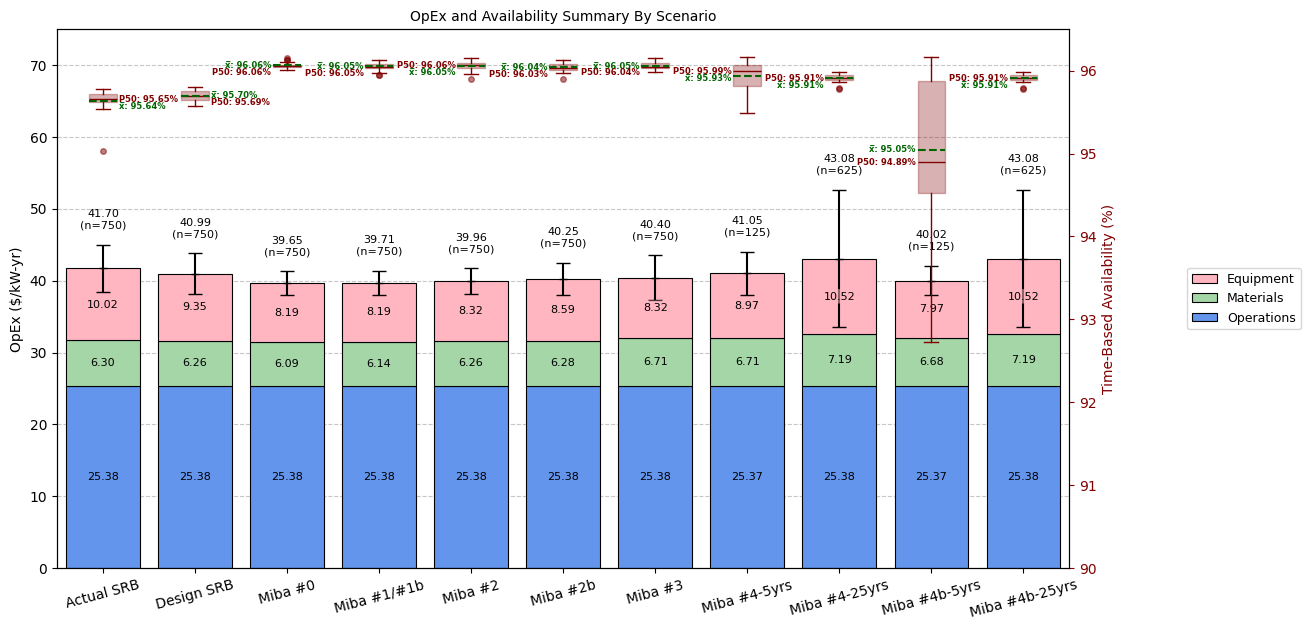

[np.float64(95.6391490132066), np.float64(95.69628218804657), np.float64(96.06393198249889), np.float64(96.0516143334276), np.float64(96.054277501071), np.float64(96.03806459528083), np.float64(96.05361121043961), np.float64(95.91059350546116), np.float64(95.76338669510997)]
Figure saved as: Figures/OpEx_Summary_ErrBar_Combined_4_4b.png


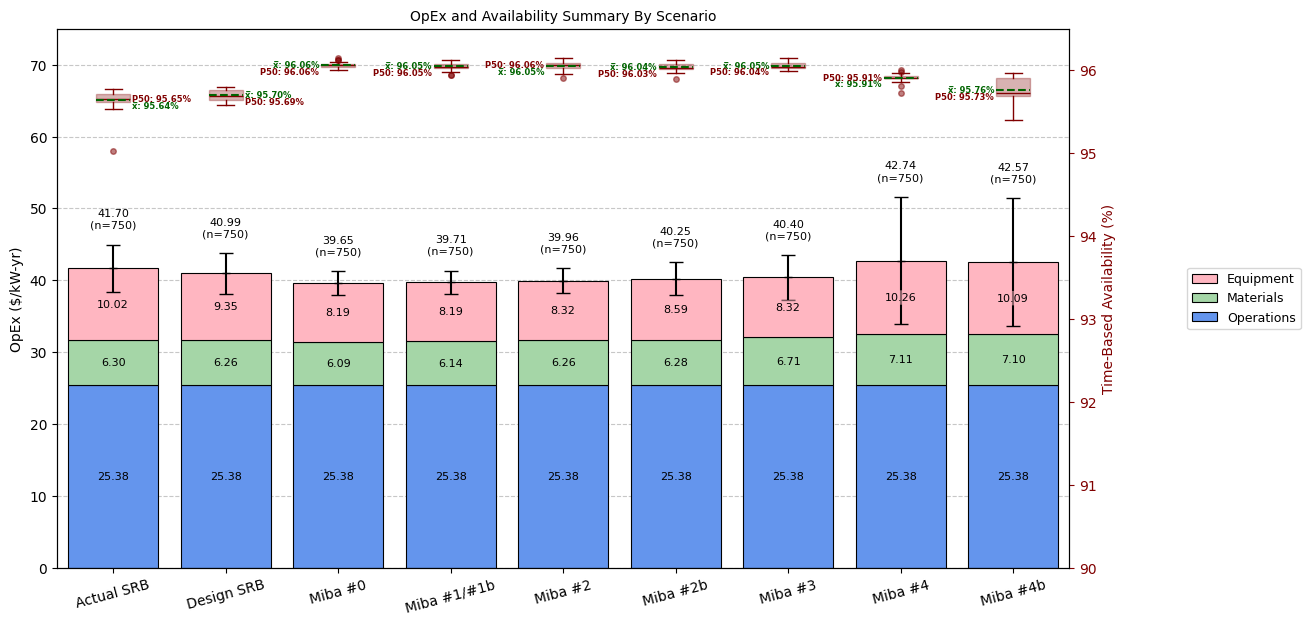

[np.float64(95.6391490132066), np.float64(95.69628218804657), np.float64(96.06393198249889), np.float64(96.0516143334276), np.float64(96.054277501071), np.float64(96.03806459528083), np.float64(96.05361121043961), np.float64(95.93152789997546), np.float64(95.9064066265583), np.float64(95.0482870378683), np.float64(95.9064066265583)]
Figure saved as: Figures/OpEx_Summary_ErrBar_SplitOps_Standard.png


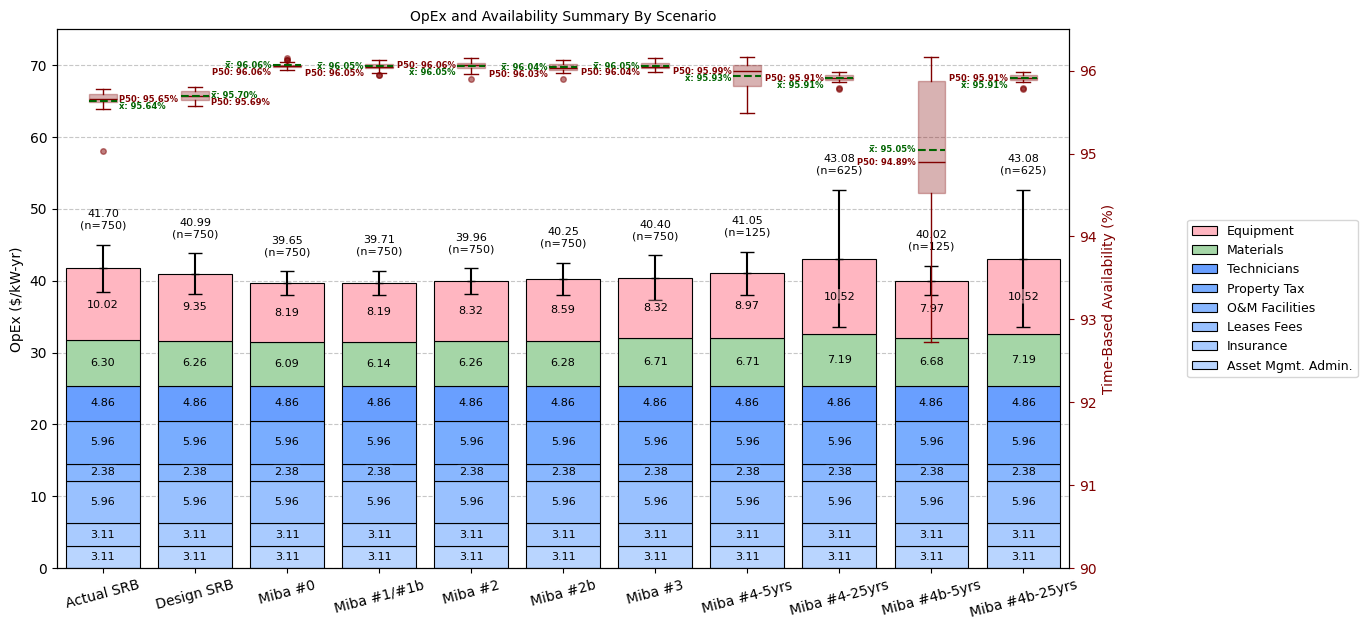

[np.float64(95.6391490132066), np.float64(95.69628218804657), np.float64(96.06393198249889), np.float64(96.0516143334276), np.float64(96.054277501071), np.float64(96.03806459528083), np.float64(96.05361121043961), np.float64(95.91059350546116), np.float64(95.76338669510997)]
Figure saved as: Figures/OpEx_Summary_ErrBar_SplitOps_Combined_4_4b.png


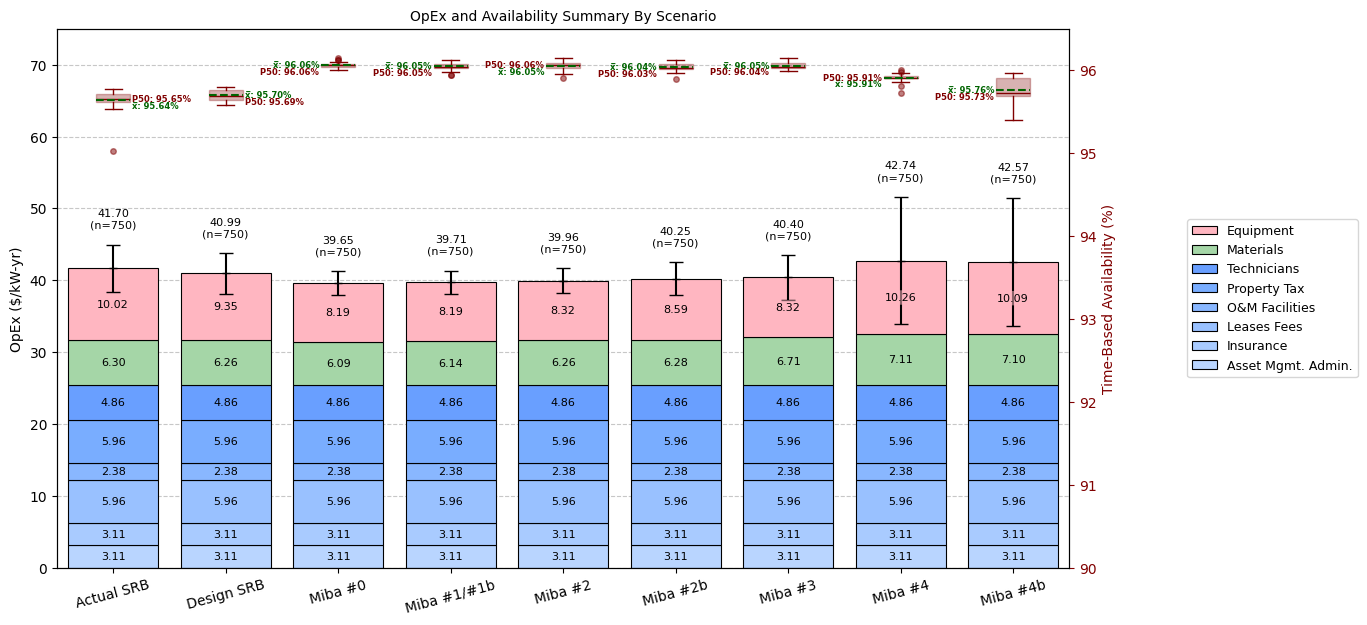

[np.float64(95.6391490132066), np.float64(95.69628218804657), np.float64(96.06393198249889), np.float64(96.0516143334276), np.float64(96.054277501071), np.float64(96.03806459528083), np.float64(96.05361121043961), np.float64(95.93152789997546), np.float64(95.9064066265583), np.float64(95.0482870378683), np.float64(95.9064066265583)]
Figure saved as: Figures/OpEx_Summary_HighRes_Standard.png


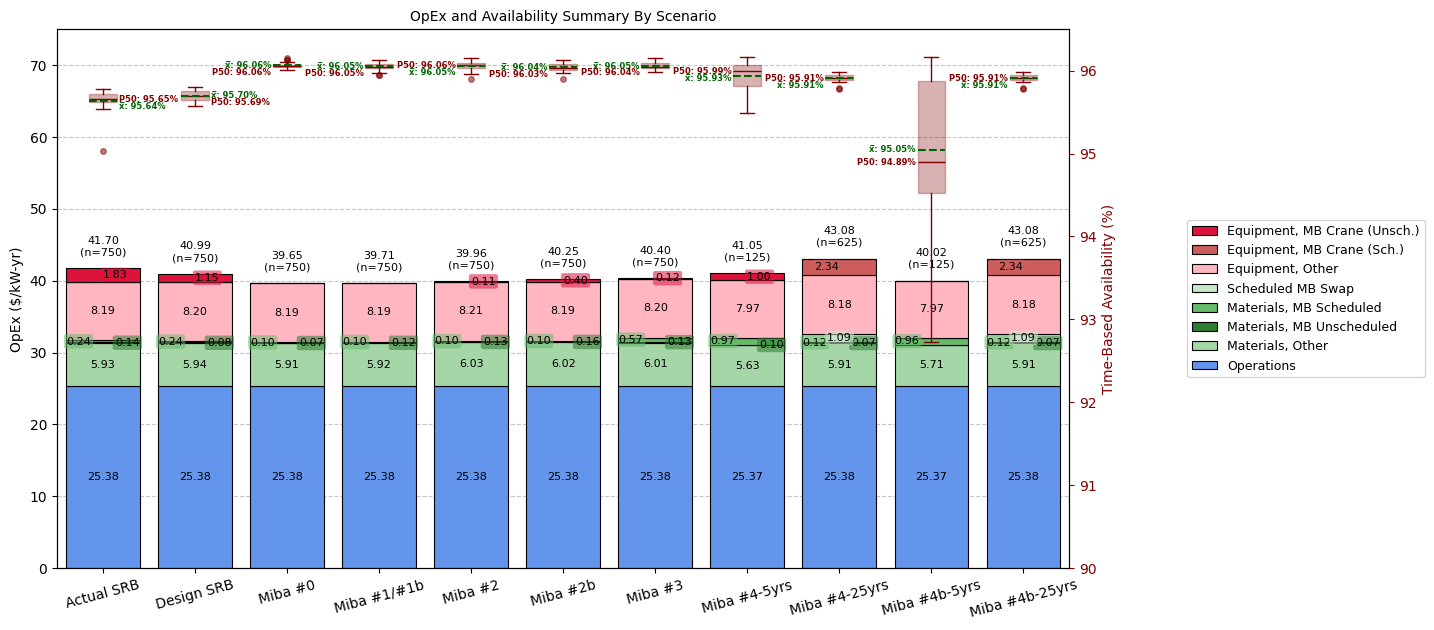

[np.float64(95.6391490132066), np.float64(95.69628218804657), np.float64(96.06393198249889), np.float64(96.0516143334276), np.float64(96.054277501071), np.float64(96.03806459528083), np.float64(96.05361121043961), np.float64(95.91059350546116), np.float64(95.76338669510997)]
Figure saved as: Figures/OpEx_Summary_HighRes_Combined_4_4b.png


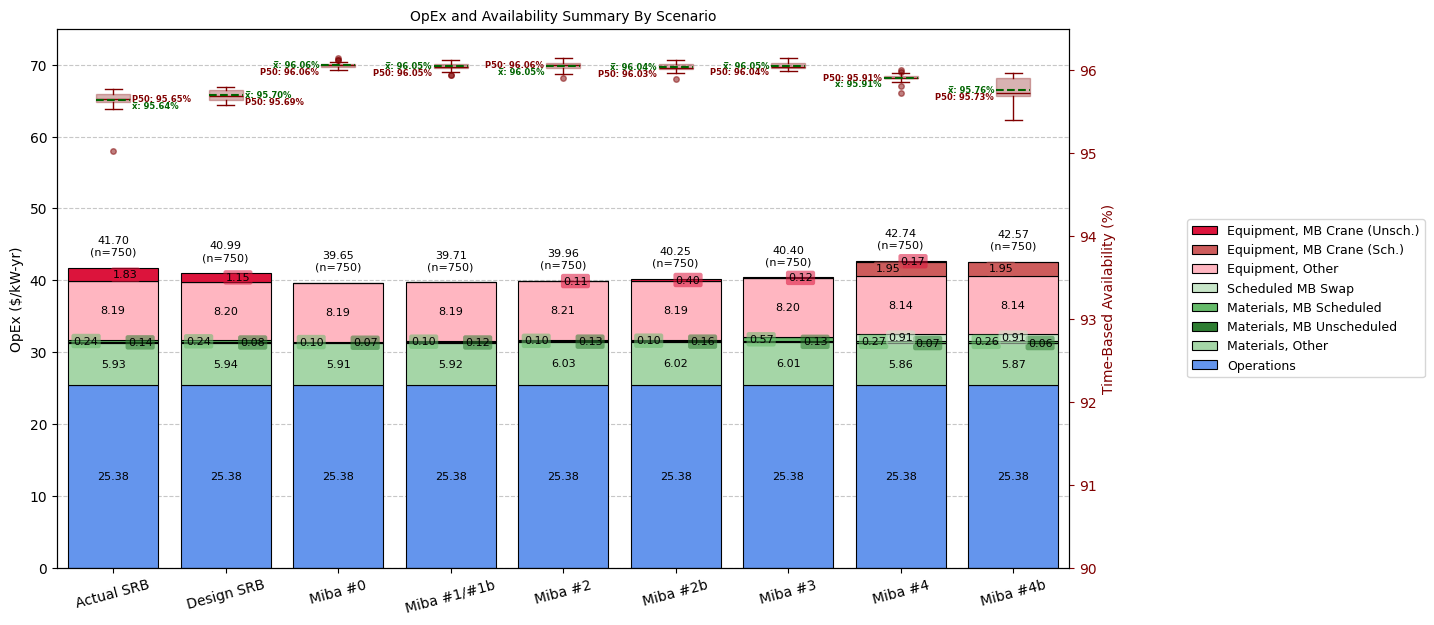

In [2]:
# Examples:
# High-resolution (detailed), split operations, no error bars
plot_opex_availability_summary_split_equipment_and_mb_materials(
    show_error_bars=True, high_resolution=False, split_operations=False, combine_case_4=False
)

plot_opex_availability_summary_split_equipment_and_mb_materials(
    show_error_bars=True, high_resolution=False, split_operations=False, combine_case_4=True
)

# Aggregated, split operations, with error bars
plot_opex_availability_summary_split_equipment_and_mb_materials(
    show_error_bars=True, high_resolution=False, split_operations=True, combine_case_4=False
)


plot_opex_availability_summary_split_equipment_and_mb_materials(
    show_error_bars=True, high_resolution=False, split_operations=True, combine_case_4=True
)

# Aggregated, split operations, with error bars
plot_opex_availability_summary_split_equipment_and_mb_materials(
    show_error_bars=False, high_resolution=True, split_operations=False, combine_case_4=False
)

plot_opex_availability_summary_split_equipment_and_mb_materials(
    show_error_bars=False, high_resolution=True, split_operations=False, combine_case_4=True
)

### Summarize Main Bearing-Related Requests

In [22]:
import pandas as pd
from pathlib import Path
from functools import reduce

def summarize_main_bearing_requests_report(library_path="../library/base_2023/results/"):
    """
    Summarize main bearing requests in a report-style table:
    Rows = task + request type, Columns = scenarios.
    Averages over multiple simulations in each CSV.
    """

    scenarios = [
        "ATB3_3_baseline_ATB",
        "ATB3_3_design_ATB",
        "ATB3_3_miba-case-0",
        "ATB3_3_miba-case-1",
        "ATB3_3_miba-case-2",
        "ATB3_3_miba-case-2b",
        "ATB3_3_miba-case-3",
        "ATB3_3_miba-case-4-5yrs",
        "ATB3_3_miba-case-4-25yrs",
        "ATB3_3_miba-case-4-5yrs",
        "ATB3_3_miba-case-4-25yrs",
        "ATB3_3_miba-case-4b-5yrs",
    ]

    request_cols = ['total_requests', 'canceled_requests', 'incomplete_requests', 'completed_requests']

    scenario_dfs = {}

    for scenario in scenarios:
        file_path = Path(library_path) / f"COWER-2025-{scenario}_requests_results.csv"
        df = pd.read_csv(file_path)

        # Filter for all main-bearing–related subassemblies
        df_mb = df[df['subassembly'].isin([
            'main_bearing_maintenance',
            'main_bearing_failures',
            'main_bearing',
            'main_bearing_installation'
        ])]

        # Group by task + request_type and average numerical columns
        df_avg = df_mb.groupby('task')[request_cols].mean().reset_index()

        # Melt so that request type becomes a column
        df_melt = df_avg.melt(id_vars=['task'], value_vars=request_cols,
                              var_name='request_type', value_name=scenario)

        scenario_dfs[scenario] = df_melt

    # Merge all scenarios on task + request_type
    df_summary = reduce(lambda left, right: pd.merge(left, right, on=['task', 'request_type'], how='outer'),
                        scenario_dfs.values())

    # Optional: sort by task then request_type
    df_summary = df_summary.sort_values(['task', 'request_type']).reset_index(drop=True)

    return df_summary


In [23]:
summarize_main_bearing_requests_report()

,task,request_type,ATB3_3_baseline_ATB,ATB3_3_design_ATB,ATB3_3_miba-case-0,ATB3_3_miba-case-1,ATB3_3_miba-case-2,ATB3_3_miba-case-2b,ATB3_3_miba-case-3,ATB3_3_miba-case-4-5yrs,ATB3_3_miba-case-4-25yrs,ATB3_3_miba-case-4b-5yrs
0,major repair,canceled_requests,NaN,NaN,0.00,0.00,0.000000,0.000000,0.000000,NaN,0.00,NaN
1,major repair,completed_requests,NaN,NaN,9.56,15.48,14.880000,14.840000,15.080000,NaN,7.28,NaN
2,major repair,incomplete_requests,NaN,NaN,0.00,0.00,0.000000,0.000000,0.040000,NaN,0.04,NaN
3,major repair,total_requests,NaN,NaN,9.56,15.48,14.880000,14.840000,15.120000,NaN,7.32,NaN
4,major replacement,canceled_requests,0.00,0.00,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
5,major replacement,completed_requests,13.64,8.40,NaN,NaN,1.333333,3.173913,1.333333,1.705882,NaN,0.000000
6,major replacement,incomplete_requests,0.20,0.08,NaN,NaN,0.000000,0.043478,0.066667,0.058824,NaN,1.764706
7,major replacement,total_requests,13.84,8.48,NaN,NaN,1.333333,3.217391,1.400000,1.764706,NaN,1.764706
8,major scheduled repair,canceled_requests,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
9,major scheduled repair,completed_requests,NaN,NaN,NaN,NaN,NaN,NaN,61.000000,NaN,NaN,NaN


### Summarize Main Bearing-Related Crane Costs

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

def summarize_large_crane_costs(library_path="../library/base_2023/results/"):
    scenarios = [
        "ATB3_3_baseline_ATB",
        "ATB3_3_design_ATB",
        "ATB3_3_miba-case-0",
        "ATB3_3_miba-case-1",
        "ATB3_3_miba-case-2",
        "ATB3_3_miba-case-2b",
        "ATB3_3_miba-case-3",
        "ATB3_3_miba-case-4-5yrs",
        "ATB3_3_miba-case-4-25yrs",
        "ATB3_3_miba-case-4-5yrs",
        "ATB3_3_miba-case-4-25yrs",
    ]

    results = {}

    for scenario in scenarios:
        df_v = pd.read_csv(Path(library_path) / f"COWER-2025-{scenario}_all_vessel_results.csv")

        # ---- FIND THE ACTUAL COLUMN NAME ----
        possible_cols = [
            c for c in df_v.columns
            if "large" in c.lower() and "crane" in c.lower() and "mb" in c.lower()
        ]

        if len(possible_cols) == 0:
            results[scenario] = np.nan
            continue

        col = possible_cols[0]  # the matched column

        results[scenario] = df_v[col].mean()

    return pd.DataFrame([results], index=["Large Crane For MB Cost"])


def add_large_crane_cost_to_mb_table(df_mb, df_crane):
    """
    Append Large Crane For MB average cost to the main-bearing summary table.
    df_mb     = output of summarize_main_bearing_requests_report()
    df_crane  = DataFrame with one row: index = 'Large Crane For MB Cost'
                and columns = scenario costs
    """

    # Build an empty row with all columns from df_mb
    new_row = {col: np.nan for col in df_mb.columns}

    # Required ID columns
    new_row["task"] = "major replacement"
    new_row["request_type"] = "Large Crane For MB Cost"

    # Fill scenario columns
    for scenario in df_crane.columns:
        if scenario in new_row:
            new_row[scenario] = df_crane.at["Large Crane For MB Cost", scenario]

    # Append row
    df_final = pd.concat([df_mb, pd.DataFrame([new_row])], ignore_index=True)

    return df_final


    return df_final


In [13]:
# Step 1: create the combined table
df = add_large_crane_cost_to_mb_table(
    summarize_main_bearing_requests_report(library_path="../library/base_2023/results/"),
    summarize_large_crane_costs(library_path="../library/base_2023/results/")
)

# Step 2: keep only "major replacement" tasks
df_filtered = df[df['task'] == "major replacement"].reset_index(drop=True)

df_filtered

,task,request_type,ATB3_3_baseline_ATB,ATB3_3_design_ATB,ATB3_3_miba-case-0,ATB3_3_miba-case-1,ATB3_3_miba-case-2,ATB3_3_miba-case-2b,ATB3_3_miba-case-3,ATB3_3_miba-case-4-5yrs,ATB3_3_miba-case-4-25yrs
0,major replacement,canceled_requests,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
1,major replacement,completed_requests,13.640000,8.400000,NaN,NaN,1.333333,3.173913,1.333333,1.705882,NaN
2,major replacement,incomplete_requests,0.200000,0.080000,NaN,NaN,0.000000,0.043478,0.066667,0.058824,NaN
3,major replacement,total_requests,13.840000,8.480000,NaN,NaN,1.333333,3.217391,1.400000,1.764706,NaN
4,major replacement,Large Crane For MB Cost,364334.508748,229164.890164,NaN,NaN,38078.917427,87163.087230,38911.331527,295411.490294,470652.712925


# Code saved to dig into envioronment and logistic sequences

sim_ATB3_3_base_case_3.to_csv("case-3-events.csv")

# Run case 3
sim_ATB3_3_miba_case_0.to_csv("case-0-events.csv")
sim_ATB3_3_miba_case_1.to_csv("case-1-events.csv")
sim_ATB3_3_miba_case_3 = run_windfarm_simulations("ATB3_3_base-case-3", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

sim_ATB3_3_miba_case_3.to_csv("case-3-events.csv")

summarize_main_bearing_requests_report()